# PH-05 — Transfer Learning: ResNet18 HAM10000 → Derm7pt

## Pipeline học thuật

```
[Stage 1 — PH04]  Pre-train ResNet18 trên HAM10000 (7 lớp)
                   └─► Lưu best checkpoint theo val_acc
                         checkpoints/resnet18_best.pth

[Stage 2 — PH05]  Khởi tạo model_target từ pretrained weights
                   └─► Thay classification head: 7 lớp → 5 lớp Derm7pt
                   └─► Fine-tune 2 phase trên Derm7pt
                         Phase 1: freeze backbone, chỉ train head
                         Phase 2: unfreeze toàn bộ, fine-tune end-to-end
```

> **Lưu ý học thuật:** `model_source` (pretrained trên HAM10000) và `model_target`
> (fine-tuned trên Derm7pt) là hai thực thể riêng biệt.  
> `model_target` được **khởi tạo từ trọng số của `model_source`**, không phải từ random weights.


## 1. Import thư viện

In [1]:
import csv
import math
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report

## 2. Thiết lập đường dẫn project

In [2]:
PROJECT_ROOT = Path.cwd().parent
SRC_DIR      = PROJECT_ROOT / 'src'

import sys
sys.path.insert(0, str(SRC_DIR))

from transforms import get_resnet_transforms

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
LOG_DIR   = PROJECT_ROOT / 'logs'
RES_DIR   = PROJECT_ROOT / 'results'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_CKPT = CKPT_DIR / 'resnet18_best.pth'
TARGET_CKPT = CKPT_DIR / 'resnet18_derm7pt_best.pth'
LOG_PATH    = LOG_DIR  / 'resnet18_derm7pt_log.csv'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project root : {PROJECT_ROOT}')
print(f'Device       : {DEVICE}')
print(f'Source ckpt  : {SOURCE_CKPT} (exists={SOURCE_CKPT.exists()})')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

Project root : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT
Device       : cpu
Source ckpt  : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\checkpoints\resnet18_best.pth (exists=True)


## 3. Cấu hình target dataset

In [3]:
# Nhãn Derm7pt (5 lớp) theo thứ tự đã định nghĩa ở notebook 02 & 03
DERM_LABELS      = ['bcc', 'mel', 'misc', 'nevus', 'sk']
DERM_TO_INDEX    = {label: idx for idx, label in enumerate(DERM_LABELS)}
NUM_CLASSES_SOURCE = 7  # HAM10000 — phải khớp kiến trúc checkpoint
NUM_CLASSES_TARGET = 5  # Derm7pt

BATCH_SIZE   = 32
NUM_EPOCHS   = 10
HEAD_EPOCHS  = 3   # Số epoch chỉ train head, sau đó unfreeze backbone
LR_HEAD      = 1e-4
LR_BACKBONE  = 1e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0

print('DERM_LABELS        =', DERM_LABELS)
print(f'NUM_CLASSES_SOURCE = {NUM_CLASSES_SOURCE}')
print(f'NUM_CLASSES_TARGET = {NUM_CLASSES_TARGET}')
print(f'HEAD_EPOCHS / NUM_EPOCHS = {HEAD_EPOCHS} / {NUM_EPOCHS}')

DERM_LABELS        = ['bcc', 'mel', 'misc', 'nevus', 'sk']
NUM_CLASSES_SOURCE = 7
NUM_CLASSES_TARGET = 5
HEAD_EPOCHS / NUM_EPOCHS = 3 / 10


## 4. DermDataset — dataset cho Derm7pt

CSV từ notebook 03 (`derm7pt_train/val.csv`) có cột `label` (string: 'nevus', 'mel', ...)
và `img_path`. Lớp này map trực tiếp sang integer, không dùng qua `SkinDataset`
vì `SkinDataset` validate theo `LABEL_MAP` cứng của HAM10000.

In [4]:
class DermDataset(Dataset):
    """
    Dataset cho Derm7pt.
    CSV cần có cột 'img_path' và 'label' (string, ví dụ 'nevus', 'mel').
    """
    def __init__(self, csv_path, label_map, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform

        if 'label' not in self.df.columns or 'img_path' not in self.df.columns:
            raise ValueError("CSV cần có cột 'label' và 'img_path'")

        self.df['int_label'] = self.df['label'].map(label_map)
        unmapped = self.df['int_label'].isna()
        if unmapped.any():
            bad = self.df.loc[unmapped, 'label'].unique()
            raise ValueError(f"Nhãn chưa có trong label_map: {bad}")
        self.df['int_label'] = self.df['int_label'].astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['int_label']

## 5. Tạo dataset và dataloader

In [5]:
train_ds = DermDataset(
    SPLIT_DIR / 'derm7pt_train.csv',
    label_map=DERM_TO_INDEX,
    transform=get_resnet_transforms('train'),
)
val_ds = DermDataset(
    SPLIT_DIR / 'derm7pt_val.csv',
    label_map=DERM_TO_INDEX,
    transform=get_resnet_transforms('val'),
)
test_ds = DermDataset(
    SPLIT_DIR / 'derm7pt_test.csv',
    label_map=DERM_TO_INDEX,
    transform=get_resnet_transforms('val'),  # không augment lúc test
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train : {len(train_ds):,}')
print(f'Val   : {len(val_ds):,}')
print(f'Test  : {len(test_ds):,}')
print('\nPhân phối nhãn (train):')
print(train_ds.df['label'].value_counts().reindex(DERM_LABELS))

Train : 413
Val   : 203
Test  : 395

Phân phối nhãn (train):
label
bcc       19
mel       90
misc      32
nevus    256
sk        16
Name: count, dtype: int64


## 6. Class weights cho Derm7pt

In [6]:
def compute_class_weights(dataset):
    counts  = dataset.df['label'].value_counts().reindex(DERM_LABELS)
    weights = 1.0 / counts.values.astype(float)
    weights = weights / weights.sum() * NUM_CLASSES_TARGET
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(train_ds).to(DEVICE)
for label, w in zip(DERM_LABELS, class_weights.cpu().numpy()):
    print(f'  {label:<8} {w:.4f}')

  bcc      1.6305
  mel      0.3442
  misc     0.9681
  nevus    0.1210
  sk       1.9362


## 7. Khởi tạo model_target từ pretrained weights (HAM10000)

Đây là bước cốt lõi của Transfer Learning:

1. **Định nghĩa hàm `init_target_model_from_pretrained()`** — hàm này đóng gói toàn bộ
   quá trình "lấy kiến thức từ model_source để tạo model_target":
   - Dựng lại đúng kiến trúc source (7 lớp) để `load_state_dict` không bị mismatch.
   - Load `model_source` pretrained weights từ checkpoint HAM10000.
   - Thay classification head: 7 lớp nguồn → 5 lớp Derm7pt (random init).
   - Freeze backbone — giữ nguyên feature extractor đã học từ HAM10000.

2. **Gọi hàm để tạo `model_target`**:
   ```python
   model_target = init_target_model_from_pretrained(SOURCE_CKPT, NUM_CLASSES_TARGET)
   ```
   Sau bước này, `model_target` mang backbone đã pretrain trên HAM10000
   và một head mới sẵn sàng học phân loại 5 lớp Derm7pt.


In [7]:
def init_target_model_from_pretrained(source_ckpt_path, num_target_classes):
    """
    Khởi tạo model_target cho Derm7pt từ pretrained weights của model_source (HAM10000).

    Pipeline:
        model_source  (pretrained on HAM10000, 7 classes)
            └─► load weights vào kiến trúc source
            └─► thay head 7 → num_target_classes
            └─► freeze backbone
        model_target  (ready to fine-tune on Derm7pt)

    Args:
        source_ckpt_path  : Path đến checkpoint tốt nhất của model_source.
        num_target_classes: Số lớp của bài toán target (Derm7pt = 5).

    Returns:
        model_target : ResNet18 mang pretrained backbone + head mới cho Derm7pt.
        source_info  : dict chứa thông tin checkpoint nguồn (epoch, val_acc).
    """
    in_features = 512  # ResNet18 fc input features

    # ── Bước 1: Dựng kiến trúc source (7 lớp) để load state_dict không mismatch ──
    model_source = models.resnet18(weights=None)
    model_source.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, NUM_CLASSES_SOURCE),
    )

    # ── Bước 2: Load pretrained weights từ HAM10000 checkpoint vào model_source ──
    source_ckpt = torch.load(source_ckpt_path, map_location=DEVICE, weights_only=False)
    model_source.load_state_dict(source_ckpt['model_state'])

    source_info = {
        'epoch'  : source_ckpt['epoch'],
        'val_acc': source_ckpt['val_acc'],
        'path'   : str(source_ckpt_path),
    }
    print(f"[model_source] Loaded pretrained checkpoint từ HAM10000")
    print(f"               epoch={source_info['epoch']}, val_acc={source_info['val_acc']:.4f}")

    # ── Bước 3: Khởi tạo model_target — sao chép toàn bộ backbone từ model_source ──
    #    Backbone (layer1-4, conv1, bn1) mang pretrained weights từ HAM10000.
    #    Classification head được thay mới (random init) cho bài toán Derm7pt.
    model_target = model_source  # model_target kế thừa toàn bộ backbone
    model_target.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_target_classes),
    )

    # ── Bước 4: Freeze backbone — chỉ train head trong Phase 1 ──
    for name, param in model_target.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False

    trainable = sum(p.numel() for p in model_target.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model_target.parameters())
    print(f"[model_target] Backbone frozen  | head mới: {num_target_classes} lớp Derm7pt")
    print(f"               Trainable params : {trainable:,} / {total:,}")

    return model_target.to(DEVICE), source_info


# ── Tạo model_target từ pretrained model_source ──
model_target, source_info = init_target_model_from_pretrained(
    source_ckpt_path   = SOURCE_CKPT,
    num_target_classes = NUM_CLASSES_TARGET,
)

print(f"\n✅ model_target sẵn sàng fine-tune trên Derm7pt")
print(f"   Backbone khởi tạo từ: {source_info['path']}")
print(f"   Pretrained val_acc (HAM10000): {source_info['val_acc']:.4f}")

[model_source] Loaded pretrained checkpoint từ HAM10000
               epoch=10, val_acc=0.7265
[model_target] Backbone frozen  | head mới: 5 lớp Derm7pt
               Trainable params : 2,565 / 11,179,077

✅ model_target sẵn sàng fine-tune trên Derm7pt
   Backbone khởi tạo từ: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\checkpoints\resnet18_best.pth
   Pretrained val_acc (HAM10000): 0.7265


## 8. Hàm train_one_epoch và validate

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

## 9. Fine-tune model_target trên Derm7pt

- **Phase 1** (epoch 1 → `HEAD_EPOCHS`): backbone **frozen** — chỉ train classification head mới.
- **Phase 2** (epoch `HEAD_EPOCHS+1` → `NUM_EPOCHS`): **unfreeze** toàn bộ — fine-tune end-to-end với LR backbone nhỏ hơn.

> Hai phase giúp tránh "catastrophic forgetting": head được ổn định trước, sau đó mới điều chỉnh dần backbone.


In [9]:
# ── Phase 1: train head | Phase 2: fine-tune end-to-end ──
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_target.fc.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'val_acc', 'lr'])

best_val_acc  = 0.0
unfreeze_done = False

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Phase 2: unfreeze backbone khi vượt qua HEAD_EPOCHS ───────────
    if epoch == HEAD_EPOCHS + 1 and not unfreeze_done:
        print('\n[Unfreeze] Mở backbone — fine-tune toàn bộ...')
        for p in model_target.parameters():
            p.requires_grad = True
        optimizer = torch.optim.Adam([
            {'params': model_target.fc.parameters(),
             'lr': LR_HEAD},
            {'params': [p for n, p in model_target.named_parameters() if 'fc' not in n],
             'lr': LR_BACKBONE},
        ], weight_decay=WEIGHT_DECAY)
        scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=3, factor=0.5
        )
        unfreeze_done = True

    t0         = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
        f'train_loss={train_loss:.4f}  '
        f'val_loss={val_loss:.4f}  '
        f'val_acc={val_acc:.4f}  '
        f'({time.time() - t0:.1f}s)'
    )

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            f'{train_loss:.6f}',
            f'{val_loss:.6f}',
            f'{val_acc:.6f}',
            f'{optimizer.param_groups[0]["lr"]:.2e}',
        ])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model_target.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc'        : val_acc,
            'val_loss'       : val_loss,
            'class_names'    : DERM_LABELS,
        }, TARGET_CKPT)
        print(f'  ✅ Saved best  val_acc={val_acc:.4f}')

print(f'\nDone. Best val_acc = {best_val_acc:.4f}')

NameError: name 'model' is not defined

## 10. Kết quả — log và biểu đồ training

In [ ]:
log_df = pd.read_csv(LOG_PATH)
print(log_df.to_string(index=False))

 epoch  train_loss  val_loss  val_acc     lr
     1    1.724024  1.622195 0.216749 0.0001
     2    1.717048  1.582657 0.261084 0.0001
     3    1.733325  1.548539 0.290640 0.0001
     4    1.629805  1.453266 0.374384 0.0001
     5    1.529054  1.380361 0.418719 0.0001
     6    1.432877  1.316815 0.507389 0.0001
     7    1.289766  1.270520 0.546798 0.0001
     8    1.259309  1.228422 0.586207 0.0001
     9    1.163186  1.199771 0.576355 0.0001
    10    1.135515  1.174292 0.596059 0.0001


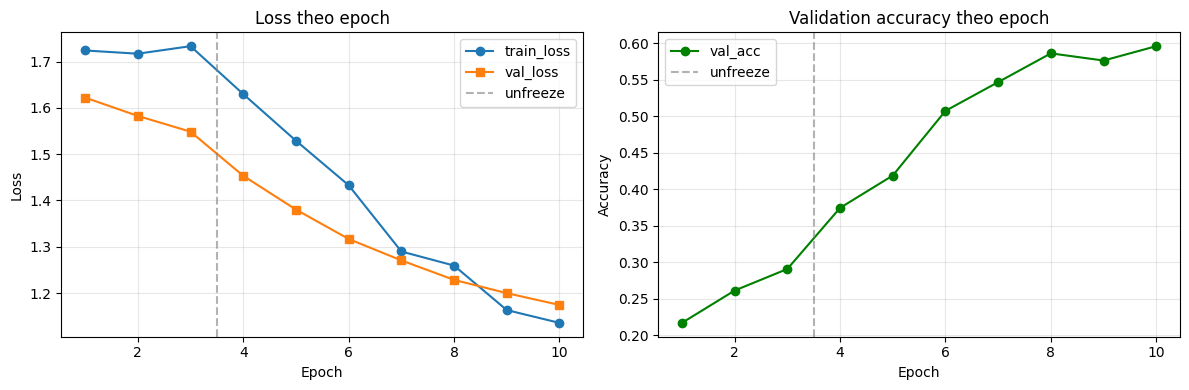

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log_df['epoch'], log_df['train_loss'], marker='o', label='train_loss')
axes[0].plot(log_df['epoch'], log_df['val_loss'],   marker='s', label='val_loss')
axes[0].axvline(HEAD_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6, label='unfreeze')
axes[0].set_title('Loss theo epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(log_df['epoch'], log_df['val_acc'], marker='o', color='green', label='val_acc')
axes[1].axvline(HEAD_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6, label='unfreeze')
axes[1].set_title('Validation accuracy theo epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RES_DIR / 'resnet18_derm7pt_training_curves.png', dpi=120)
plt.show()

## 11. Đánh giá model_target trên test set

Load best checkpoint của `model_target` (đã fine-tune trên Derm7pt) và đánh giá accuracy, loss.


In [ ]:
# Load best checkpoint
best_ckpt = torch.load(TARGET_CKPT, map_location=DEVICE, weights_only=False)
model_target.load_state_dict(best_ckpt['model_state'])
print(f"Best checkpoint   : epoch={best_ckpt['epoch']}, val_acc={best_ckpt['val_acc']:.4f}")

# Đánh giá trên test set
test_loss, test_acc = validate(model_target, test_loader, criterion)
print(f"Test loss         : {test_loss:.4f}")
print(f"Test accuracy     : {test_acc:.4f}")

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds, all_labels = [], []
model_target.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = model_target(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES_TARGET))
ax.set_yticks(range(NUM_CLASSES_TARGET))
ax.set_xticklabels(DERM_LABELS, rotation=45, ha='right')
ax.set_yticklabels(DERM_LABELS)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test set  (acc={test_acc:.4f})')

for i in range(NUM_CLASSES_TARGET):
    for j in range(NUM_CLASSES_TARGET):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
fig.savefig(RES_DIR / 'resnet18_derm7pt_confusion_matrix.png', dpi=120)
plt.show()

print('\nClassification report:')
print(classification_report(all_labels, all_preds, target_names=DERM_LABELS))

## 12. Lưu classification report ra file

In [ ]:
report_str = classification_report(all_labels, all_preds, target_names=DERM_LABELS, digits=4)
print(report_str)
report_path = RES_DIR / 'resnet18_derm7pt_classification_report.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(f"model_target fine-tuned from HAM10000 (val_acc={source_info['val_acc']:.4f})\n\n")
    f.write(report_str)
print(f"Saved: {report_path}")

### 13. Visualize dự đoán — 10 ảnh từ test set (xanh = đúng, đỏ = sai)

In [ ]:
import random
import matplotlib.patches as mpatches

# ── Load best checkpoint (nếu chưa load) ──────────────────────────────────
best_ckpt = torch.load(TARGET_CKPT, map_location=DEVICE, weights_only=False)
model_target.load_state_dict(best_ckpt['model_state'])
model_target.eval()

# ── Lấy ngẫu nhiên 10 mẫu từ test set ────────────────────────────────────
NUM_SHOW = 10
indices = random.sample(range(len(test_ds)), NUM_SHOW)

images_raw = []   # ảnh gốc (PIL, chưa normalize)
images_tensor = [] # tensor đã transform
true_labels = []

val_transform = get_resnet_transforms('val')

for idx in indices:
    row = test_ds.df.iloc[idx]
    img_pil = Image.open(row['img_path']).convert('RGB')
    images_raw.append(img_pil)
    images_tensor.append(val_transform(img_pil))
    true_labels.append(int(row['int_label']))

# ── Predict ───────────────────────────────────────────────────────────────
batch = torch.stack(images_tensor).to(DEVICE)
with torch.no_grad():
    outputs = model_target(batch)
    probs   = torch.softmax(outputs, dim=1)
    preds   = outputs.argmax(1).cpu().numpy()

# ── Vẽ 2 hàng x 5 cột ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    correct   = (preds[i] == true_labels[i])
    border_c  = '#2ecc71' if correct else '#e74c3c'   # xanh / đỏ
    conf      = probs[i][preds[i]].item()

    ax.imshow(images_raw[i])
    ax.axis('off')

    # Khung màu xanh/đỏ
    for spine in ax.spines.values():
        spine.set_edgecolor(border_c)
        spine.set_linewidth(5)
        spine.set_visible(True)

    status = '✓' if correct else '✗'
    title  = (
        f"{status} Pred: {DERM_LABELS[preds[i]]}\n"
        f"True: {DERM_LABELS[true_labels[i]]}  ({conf:.0%})"
    )
    ax.set_title(title, fontsize=10,
                 color=border_c, fontweight='bold', pad=6)

# Legend
patch_ok  = mpatches.Patch(color='#2ecc71', label='Đúng')
patch_err = mpatches.Patch(color='#e74c3c', label='Sai')
fig.legend(handles=[patch_ok, patch_err], loc='lower center',
           ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Dự đoán 10 ảnh ngẫu nhiên từ Test set (ResNet18 fine-tuned on Derm7pt)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(RES_DIR / 'resnet18_derm7pt_sample_predictions.png',
            dpi=120, bbox_inches='tight')
plt.show()
print(f'Đúng: {sum(preds[i]==true_labels[i] for i in range(NUM_SHOW))}/{NUM_SHOW}')
